In [1]:
# --- 1 --- PRIPOJENI K DB + NASTAVENI SQL DOTAZU #

import pandas as pd
from sqlalchemy import create_engine, text
import urllib.parse
    
# Připojení k DB Valuo pomocí SQLAlchemy
params_conn = urllib.parse.quote_plus(
        "Driver={ODBC Driver 17 for SQL Server};"
        "Server=RYZEN9;"
        "Database=VALUO;"
        "UID=jete_lokalni_pripojeni_valuo;"
        "PWD=jete.666;"
    )
connection_url = f"mssql+pyodbc:///?odbc_connect={params_conn}"

#params_conn = urllib.parse.quote_plus(
#        "Driver={ODBC Driver 17 for SQL Server};"
#        "Server=RYZEN9;"
#        "Database=VALUO;"
#        "Trusted_Connection=yes;"
#    )
#connection_url = f"mssql+pyodbc:///?odbc_connect={params_conn}"





engine = create_engine(connection_url)

ImportError: dlopen(/Users/jantrubac/Documents/GitHub/DATA_ANALYSIS/.venv/lib/python3.9/site-packages/pyodbc.cpython-39-darwin.so, 0x0002): Library not loaded: /opt/homebrew/opt/unixodbc/lib/libodbc.2.dylib
  Referenced from: <972B4929-ED5A-3A5E-A250-DE176888FE6B> /Users/jantrubac/Documents/GitHub/DATA_ANALYSIS/.venv/lib/python3.9/site-packages/pyodbc.cpython-39-darwin.so
  Reason: tried: '/opt/homebrew/opt/unixodbc/lib/libodbc.2.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/unixodbc/lib/libodbc.2.dylib' (no such file), '/opt/homebrew/opt/unixodbc/lib/libodbc.2.dylib' (no such file)

In [2]:
# --- 2 --- QUERY

query = """





WITH Base AS (
    SELECT
        vd.cislo_vkladu AS vklad,
        CAST(vd.datum_podani AS date) AS datum,
        vd.nemovitost,
        vd.typ AS typ_nemovitosti,
        vd.cenovy_udaj AS cena,
        vd.mena,
        vd.plocha,
        vd.typ_plochy,
        vd.okres,
        vd.kat_uzemi,
        vd.adresa,
        vd.popis,
        LOWER(vd.nemovitost) AS nemovitost_lc,
        LOWER(vd.typ) AS typ_lc
    FROM dbo.Valuo_data vd
),

PerVklad AS (
    SELECT
        vklad,
        -- oznacuje vklady kde je nejaky typ_nemovitosti = 'Neznámé'
        COUNT(CASE WHEN typ_nemovitosti = 'Neznámé' THEN 1 END) AS pocet_neznamych,

        -- oznacuje vklady kde je nejaka nemovitost s plochou = 0
        COUNT(CASE WHEN Plocha = 0 THEN 1 END) AS pocet_0_ploch,


        -- součet ploch parcel ve vkladu
        SUM(CASE 
                WHEN nemovitost_lc LIKE '%parcela%' 
                    THEN plocha 
                ELSE 0 
            END) AS soucet_plochy_parcel,

        COUNT(*) AS pocet_nemovitosti,
        SUM(CASE WHEN nemovitost_lc LIKE '%parcela%' THEN 1 ELSE 0 END) AS pocet_parcel,
        SUM(CASE WHEN nemovitost_lc LIKE '%budova%'  THEN 1 ELSE 0 END) AS pocet_budov,
        SUM(CASE WHEN nemovitost_lc LIKE '%jednotka%' THEN 1 ELSE 0 END) AS pocet_jednotek,

        SUM(CASE WHEN typ_lc LIKE 'by%'                 THEN 1 ELSE 0 END) AS pocet_bytu,
        SUM(CASE WHEN typ_lc LIKE '%nebyt%'             THEN 1 ELSE 0 END) AS pocet_NEbytu,
        SUM(CASE WHEN typ_lc LIKE '%rodinný dům%'       THEN 1 ELSE 0 END) AS pocet_rd,
        SUM(CASE WHEN typ_lc LIKE '%objekt k bydlení%'  THEN 1 ELSE 0 END) AS pocet_objbyd,

        SUM(CASE 
                WHEN nemovitost_lc LIKE '%budova%' 
                 AND typ_lc        LIKE '%garáž%' 
                    THEN 1 
                ELSE 0 
            END) AS pocet_garaz_budova,

        SUM(CASE 
                WHEN nemovitost_lc LIKE '%jednotka%' 
                 AND typ_lc        LIKE '%garáž%' 
                    THEN 1 
                ELSE 0 
            END) AS pocet_garaz_jednotka,

        SUM(CASE WHEN typ_lc LIKE '%stavba ubytovacího zařízení%' THEN 1 ELSE 0 END) AS pocet_ubytovani,
        SUM(CASE WHEN typ_lc LIKE '%stavba pro obchod%'           THEN 1 ELSE 0 END) AS pocet_obchod,
        SUM(CASE WHEN typ_lc LIKE '%víceúčelová stavba%'          THEN 1 ELSE 0 END) AS pocet_viceucel
    FROM Base
    GROUP BY vklad
),

-- Filtrování vystupu
FilteredVklady AS (
    SELECT *
    FROM PerVklad
	WHERE 1=1
          AND pocet_neznamych = 0 -- *ignoruje ty vklady kde je alespon jedna nemovitost (typ_nemovitosti = 'Neznámé')
          AND pocet_0_ploch = 0 -- *ignoruje ty vklady kde je alespon jedna nemovitost (Plocha = 0)

          --/* vklady kde je pouze n-parcel */ AND pocet_nemovitosti = pocet_parcel 


	      --/* vklady kde je pouze 1 jednotka + n ostatniho*/ AND  pocet_jednotek = 1

	      --/* vklady kde je pouze 1 byt */ AND  pocet_bytu = 1
	      --/* vklady kde je 0 RD */ AND  pocet_budov = 0
      	  --/* vklady kde je pouze 1 byt */ AND  pocet_nemovitosti = 1

	      --/* vklady kde je pouze 1 RD */ AND  pocet_rd = 1
		  --/* vklady kde je pouze 1 RD */ AND  pocet_jednotek = 0
)

SELECT
    -- 1) ID, vklad, datum
    DENSE_RANK() OVER (ORDER BY b.datum DESC, b.vklad) AS id,
    b.vklad,
    CONVERT(varchar(10), b.datum, 120) AS datum,

    -- 2) nemovitost, typ, plocha, součet ploch
    b.nemovitost,
    b.typ_nemovitosti,
    b.plocha,
    f.soucet_plochy_parcel,
    b.typ_plochy,

    -- 3) cena, měna, typ plochy
    b.mena,
    b.cena,
    -- pocitani prumerne JC na celkovou plochu vsech parcel v ramci vkladu ,u tech vkladu kde jsou pouze parcely
	CASE 
       WHEN (f.soucet_plochy_parcel = 0 OR b.typ_plochy <> 'Výměra parcely' OR pocet_nemovitosti<>pocet_parcel) THEN NULL 
       ELSE ROUND(b.cena / f.soucet_plochy_parcel, 0) 
    END AS JC_na_parcelu,

	-- pocitani JC na plochu dle podilu u bytu
	CASE 
       WHEN b.plocha = 0 OR b.typ_plochy <> 'Plocha spočítaná z podílu na budově' THEN NULL 
       ELSE ROUND(b.cena / b.plocha, 0) 
    END AS JC_na_jednotku,


    -- 4) lokalita + popis
    b.okres,
    b.kat_uzemi,
    b.adresa,
    b.popis,

    -- 5) agregace typů nemovitostí
    f.pocet_nemovitosti,
    f.pocet_parcel,
    f.pocet_budov,
    f.pocet_jednotek,
    f.pocet_bytu,
    f.pocet_NEbytu,
    f.pocet_rd,
    f.pocet_objbyd,
    f.pocet_garaz_budova,
    f.pocet_garaz_jednotka,
    f.pocet_ubytovani,
    f.pocet_obchod,
    f.pocet_viceucel

FROM Base b
JOIN FilteredVklady f ON f.vklad = b.vklad

WHERE 1=1
      --AND b.okres     = N'Praha-východ'
      --AND b.kat_uzemi = N'Pražské Předměstí'
      --AND b.kat_uzemi = N'Nová ves u Prahy'
	  --AND plocha = 0

    --AND  b.nemovitost = 'Neznámé'
	--AND  typ_nemovitosti = 'Neznámé'


ORDER BY
    id,
    b.nemovitost;



"""

df_input = pd.read_sql(query, engine)


--- STRUKTURA DATAFRAMU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85483 entries, 0 to 85482
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    85483 non-null  int64  
 1   vklad                 85483 non-null  object 
 2   datum                 85483 non-null  object 
 3   nemovitost            85483 non-null  object 
 4   typ_nemovitosti       85483 non-null  object 
 5   plocha                85483 non-null  float64
 6   soucet_plochy_parcel  85483 non-null  float64
 7   typ_plochy            85483 non-null  object 
 8   mena                  85483 non-null  object 
 9   cena                  85483 non-null  float64
 10  JC_na_parcelu         11212 non-null  float64
 11  JC_na_jednotku        37799 non-null  float64
 12  okres                 85483 non-null  object 
 13  kat_uzemi             85483 non-null  object 
 14  adresa                85483 non-null  obj

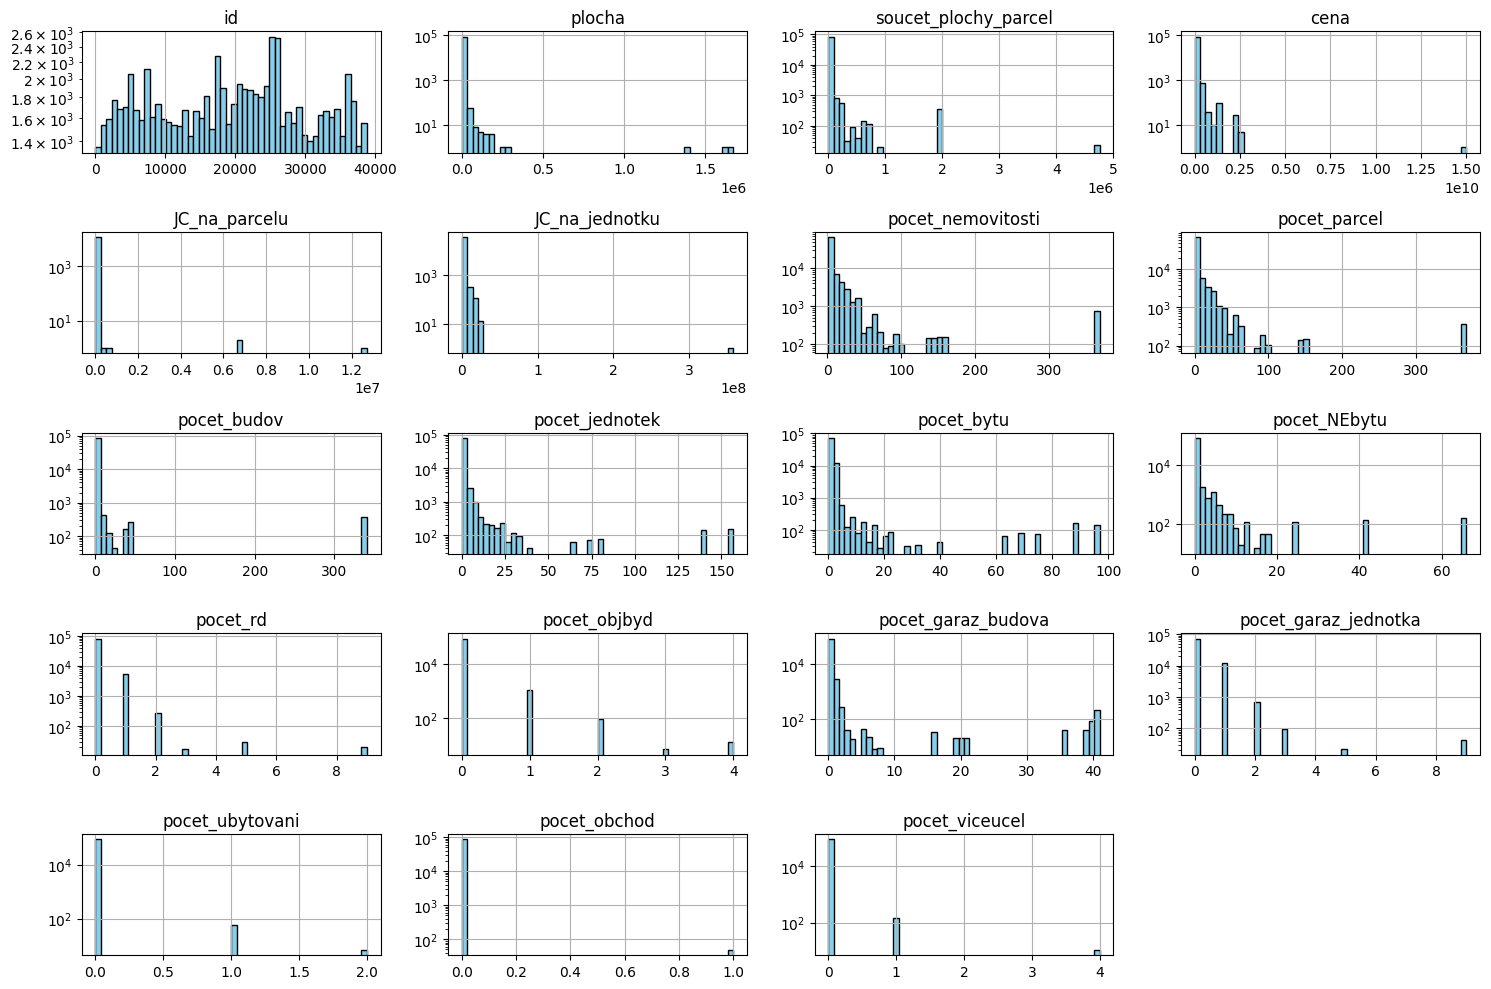


--- PRVNÍCH 20 ZÁZNAMŮ (TEXTOVÁ TABULKA) ---
+------+------------------+------------+--------------+-----------------------+----------+------------------------+-------------------------------------+--------+-------------+-----------------+------------------+--------------------+-------------+-------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------+----------------+---------------+------------------+--------------+----------------+------------+----------------+----------------------+------------------------+-------------------+----------------+------------------+
|   id | vklad            | datum      | nemovitost   | typ_nemovitosti       |   plocha |   soucet_plochy_parcel | typ_plochy                          | mena   |        cena |   JC_na_parcelu |   JC_na_j

In [3]:
# import pyodbc

print("\n--- STRUKTURA DATAFRAMU ---")
df_input.info()
print("\n\n")


import matplotlib.pyplot as plt
print("\n--- HISTOGRAMY (Logaritmická osa Y) ---")
# Parametr log=True převede osu Y na logaritmické měřítko
df_input.hist(figsize=(15, 10), bins=50, color='skyblue', edgecolor='black', log=True)
plt.tight_layout()
plt.show()



from tabulate import tabulate
print("\n--- PRVNÍCH 20 ZÁZNAMŮ (TEXTOVÁ TABULKA) ---")
# Vytvoří úhlednou tabulku s ohraničením
print(tabulate(df_input.head(20), headers='keys', tablefmt='psql', showindex=False))
